<a href="https://colab.research.google.com/github/Tejaswimadastu/Deep_Learning/blob/main/Car_Price_Prediction(TensorFlow).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## AI System for Car Price Prediction
Business Scenario A used car marketplace company wants to build an AI-based price recommendation system. Currently, dealers manually estimate the price of cars based on experience. This often leads to: Incorrect pricing Loss of potential buyers Inconsistent valuations To solve this, the company wants to build an AI model that predicts the price of a car automatically based on its features.

Build a Feed Forward Neural Network model that predicts the price of a car using the provided dataset. The system should learn relationships between features such as: Car brand Fuel type Engine size Mileage Transmission Other attributes and predict the expected car price.

CarPrice_dataset.csv The dataset contains multiple features describing different cars. Example features may include: brand fuel type engine size mileage transmission horsepower number of doors car body type Target variable: Price

🔹 Task 1 — Data Understanding Load the dataset and analyze it. Students must: Load dataset using pandas Display first 5 rows Check dataset information Check missing values Show statistical summary

🔹 Task 2 — Data Cleaning Students must: Handle missing values Remove duplicates Fix inconsistent data types

🔹 Task 3 — Data Preprocessing Students must prepare data for neural network. Required steps: Encode categorical variables Example: Fuel Type → Petrol / Diesel → One Hot Encoding Transmission → Manual / Automatic Normalize numerical features Example: MinMaxScaler or StandardScaler Split dataset Train → 80% Test → 20%

🔹 Task 4 — Build Feed Forward Neural Network must design an FNN model. Architecture example: Input Layer → Hidden Layer → Hidden Layer → Output Layer Example configuration: Input Layer: Number of features Hidden Layer 1: 64 neurons (ReLU) Hidden Layer 2: 32 neurons (ReLU) Output Layer: 1 neuron (Price)
Task 5 — Train the Model You must train the neural network. Example configuration: Loss Function → Mean Squared Error Optimizer → Adam Epochs → 50 Batch Size → 32 You must visualize: Training Loss vs Epochs

In [1]:
import pandas as pd

df = pd.read_csv("CarPrice_dataset.csv")

print(df.head())

print(df.info())

print(df.isnull().sum())

print(df.describe())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

# Task 2 — Data Cleaning
Steps

• Handle missing values
• Remove duplicates
• Fix data types

In [2]:
df = df.drop_duplicates()

df = df.dropna()

print(df.dtypes)

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object


#Task 3 — Data Preprocessing
1. Encode categorical variables

Example columns:

brand

fuel type

transmission

car body type

2. Normalize numerical values
3. Split dataset

#Task 4 — Build Feed Forward Neural Network

Architecture

Input Layer → 64 → 32 → Output

In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]

X = pd.get_dummies(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42
)

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
optimizer='adam',
loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
history = model.fit(
X_train,
y_train,
epochs=50,
batch_size=32,
validation_data=(X_test, y_test)
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 244718864.0000 - val_loss: 260932016.0000
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 234118144.0000 - val_loss: 260911456.0000
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 238273648.0000 - val_loss: 260892128.0000
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 235656112.0000 - val_loss: 260873264.0000
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 213331056.0000 - val_loss: 260854080.0000
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 226448048.0000 - val_loss: 260833360.0000
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 235155680.0000 - val_loss: 260810272.0000
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 224612160.0000 - val_loss: 260785520.0000
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 222273200.0000 - val_loss: 260756880.0000
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 208107408.0000 - val_loss: 260725360.0000
Epoch 11/

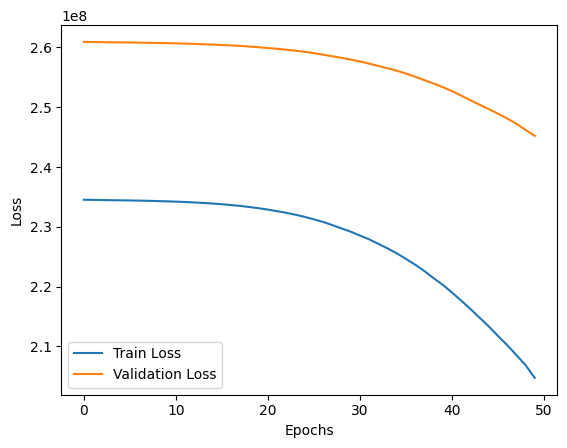

In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train Loss","Validation Loss"])

plt.show()

In [7]:
loss = model.evaluate(X_test, y_test)
print("Test Loss:", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 249201824.0000
Test Loss: 245211856.0
